# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- **Nama:** Linda Putriani
- **Email:** lindaptrn@gmail.com
- **Id Dicoding:** linda_ptrn

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
import joblib
import os

print('Libraries loaded successfully!')

Libraries loaded successfully!


### Menyiapkan data yang akan digunakan

In [2]:
df = pd.read_csv('data.csv', sep=';')
print(f'Dataset shape: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}')
df.head()

Dataset shape: (4424, 37)
Jumlah baris: 4424, Jumlah kolom: 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [3]:
# Informasi dasar dataset
print('=== INFO DATASET ===')
df.info()
print()
print('=== MISSING VALUES ===')
print(df.isnull().sum().sum(), 'total missing values')
print()
print('=== DISTRIBUSI TARGET (Status) ===')
print(df['Status'].value_counts())
print()
print(df['Status'].value_counts(normalize=True).round(3) * 100, '%')

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                     

In [4]:
# Statistik deskriptif
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


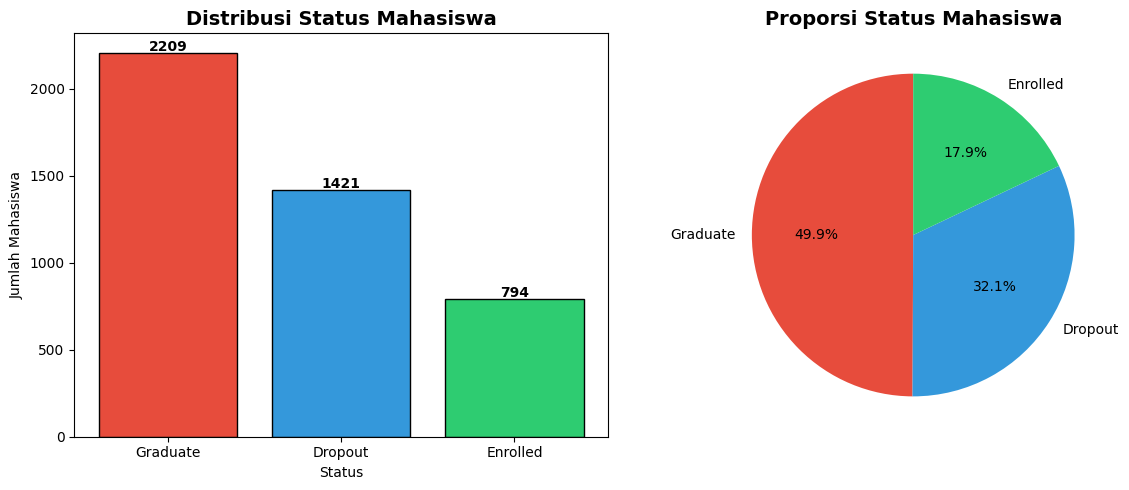

Total mahasiswa: 4424
Dropout rate: 32.1%


In [5]:
# Visualisasi distribusi Status
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
status_counts = df['Status'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[0].bar(status_counts.index, status_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Mahasiswa')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Proporsi Status Mahasiswa', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('status_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Total mahasiswa:', len(df))
print('Dropout rate:', f"{status_counts['Dropout']/len(df)*100:.1f}%")

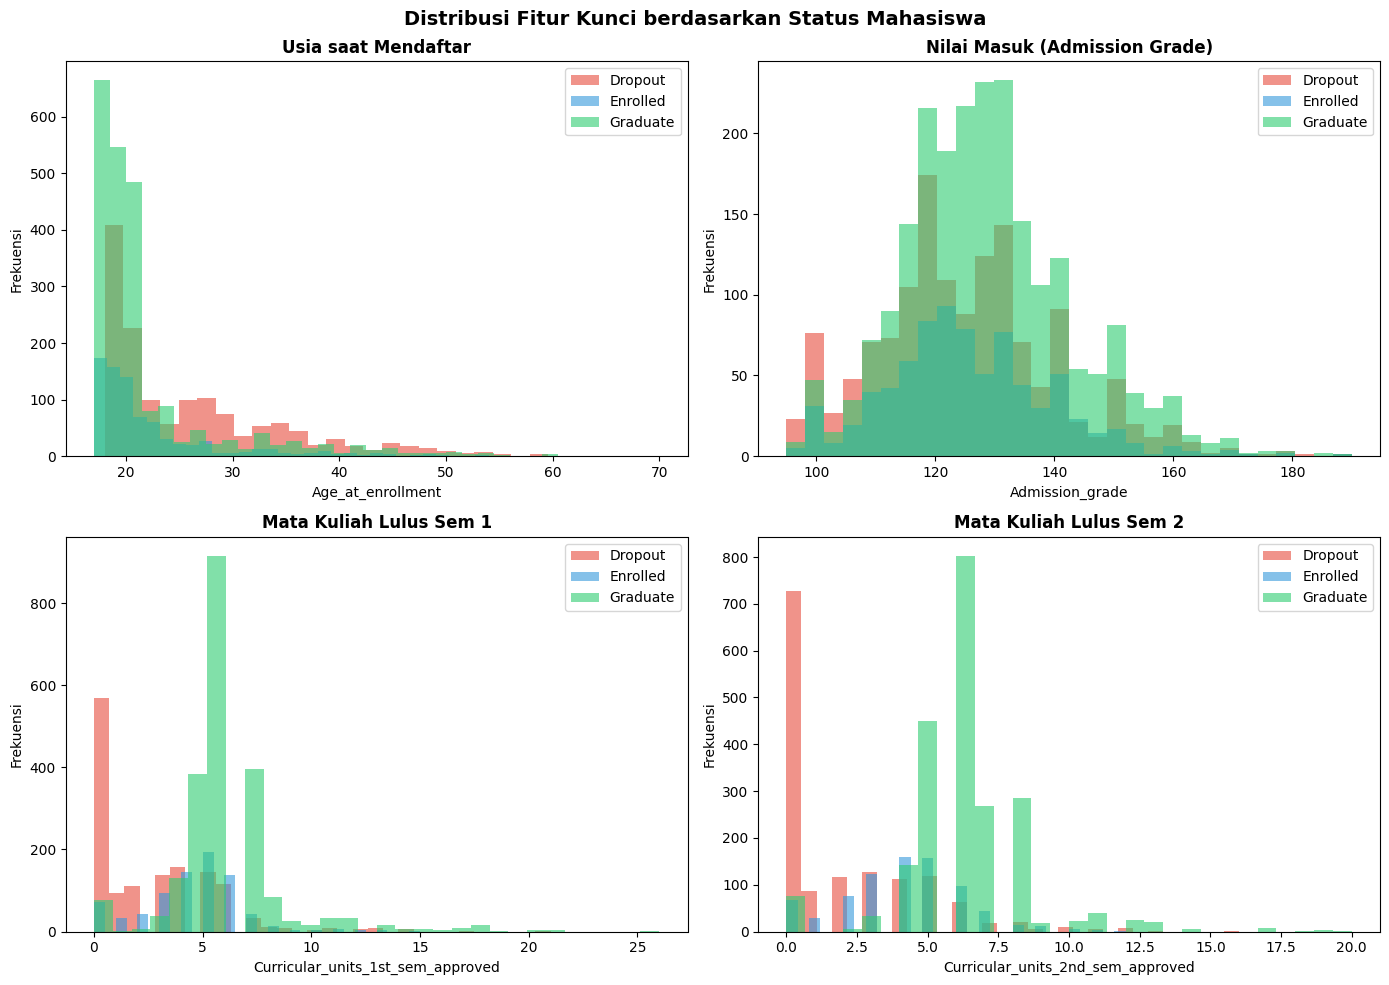

In [6]:
# Analisis fitur numerik kunci
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

key_features = [
    'Age_at_enrollment',
    'Admission_grade',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_2nd_sem_approved'
]
labels = ['Usia saat Mendaftar', 'Nilai Masuk (Admission Grade)',
          'Mata Kuliah Lulus Sem 1', 'Mata Kuliah Lulus Sem 2']

for ax, feat, label in zip(axes.ravel(), key_features, labels):
    for status, color in zip(['Dropout', 'Enrolled', 'Graduate'], ['#e74c3c','#3498db','#2ecc71']):
        ax.hist(df[df['Status']==status][feat], bins=30, alpha=0.6, label=status, color=color)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frekuensi')
    ax.legend()

plt.suptitle('Distribusi Fitur Kunci berdasarkan Status Mahasiswa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

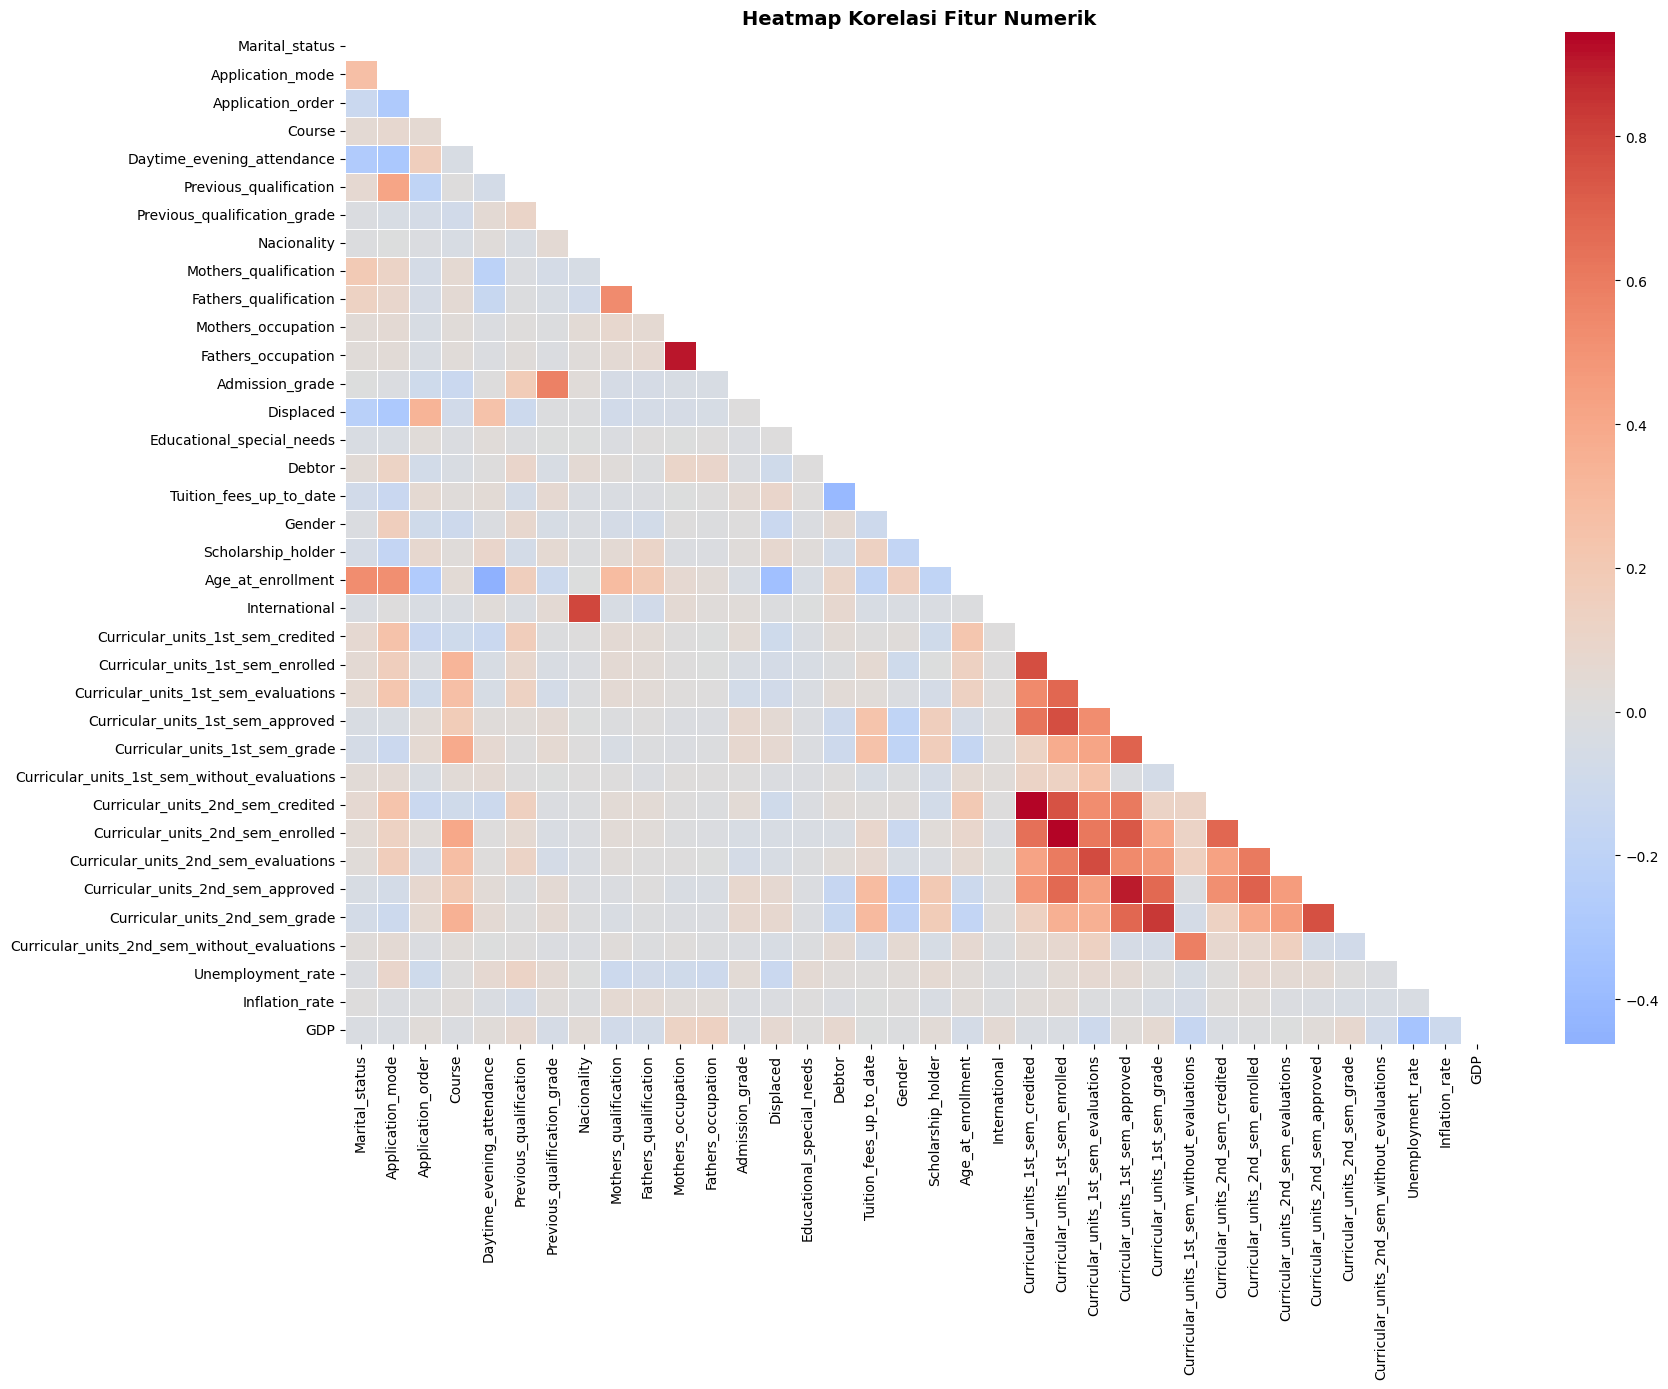

In [7]:
# Analisis korelasi fitur numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## Data Preparation / Preprocessing

In [8]:
# Encode target variable
le = LabelEncoder()
df['Status_encoded'] = le.fit_transform(df['Status'])
print('Label Encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

# Pisahkan fitur dan target
X = df.drop(['Status', 'Status_encoded'], axis=1)
y = df['Status_encoded']

print(f'\nShape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'Distribusi kelas:\n{pd.Series(y).value_counts()}')

Label Encoding:
  0 -> Dropout
  1 -> Enrolled
  2 -> Graduate

Shape X: (4424, 36)
Shape y: (4424,)
Distribusi kelas:
Status_encoded
2    2209
0    1421
1     794
Name: count, dtype: int64


In [9]:
# Train-test split (80:20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} sampel')
print(f'Testing set  : {X_test.shape[0]} sampel')

# Standardisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\nStandardisasi selesai.')
print(f'Mean fitur pertama (train): {X_train_scaled[:, 0].mean():.4f}')
print(f'Std  fitur pertama (train): {X_train_scaled[:, 0].std():.4f}')

Training set : 3539 sampel
Testing set  : 885 sampel

Standardisasi selesai.
Mean fitur pertama (train): -0.0000
Std  fitur pertama (train): 1.0000


## Modeling

In [10]:
# === Model 1: Logistic Regression ===
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print(f'Accuracy (LR): {accuracy_score(y_test, y_pred_lr):.4f}')

# === Model 2: Random Forest ===
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print(f'Accuracy (RF): {accuracy_score(y_test, y_pred_rf):.4f}')

# === Model 3: Gradient Boosting (Best) ===
print('Training Gradient Boosting...')
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)
print(f'Accuracy (GB): {accuracy_score(y_test, y_pred_gb):.4f}')

print('\nSemua model selesai dilatih!')

Training Logistic Regression...
Accuracy (LR): 0.7684
Training Random Forest...
Accuracy (RF): 0.7638
Training Gradient Boosting...
Accuracy (GB): 0.7593

Semua model selesai dilatih!


In [11]:
# Simpan model terbaik (Gradient Boosting)
os.makedirs('model', exist_ok=True)
joblib.dump(gb, 'model/gb_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
joblib.dump(le, 'model/label_encoder.pkl')
print('Model tersimpan di folder model/')

Model tersimpan di folder model/


## Evaluation

In [12]:
# Perbandingan performa semua model
models = {
    'Logistic Regression': (lr, y_pred_lr),
    'Random Forest'       : (rf, y_pred_rf),
    'Gradient Boosting'   : (gb, y_pred_gb),
}

print('=' * 60)
print(f'{"Model":<25} {"Accuracy":>10} {"F1 (weighted)":>15}')
print('=' * 60)
for name, (model, pred) in models.items():
    acc = accuracy_score(y_test, pred)
    f1  = f1_score(y_test, pred, average='weighted')
    print(f'{name:<25} {acc:>10.4f} {f1:>15.4f}')
print('=' * 60)
print('Model terbaik: Gradient Boosting')

Model                       Accuracy   F1 (weighted)
Logistic Regression           0.7684          0.7531
Random Forest                 0.7638          0.7493
Gradient Boosting             0.7593          0.7504
Model terbaik: Gradient Boosting


In [13]:
# Classification report detail model terbaik
print('=== Classification Report — Gradient Boosting ===')
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))

=== Classification Report — Gradient Boosting ===
              precision    recall  f1-score   support

     Dropout       0.80      0.73      0.76       284
    Enrolled       0.53      0.41      0.46       159
    Graduate       0.80      0.90      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



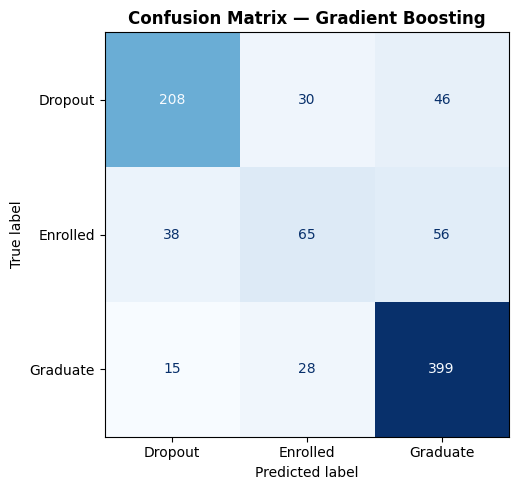

In [14]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Gradient Boosting', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

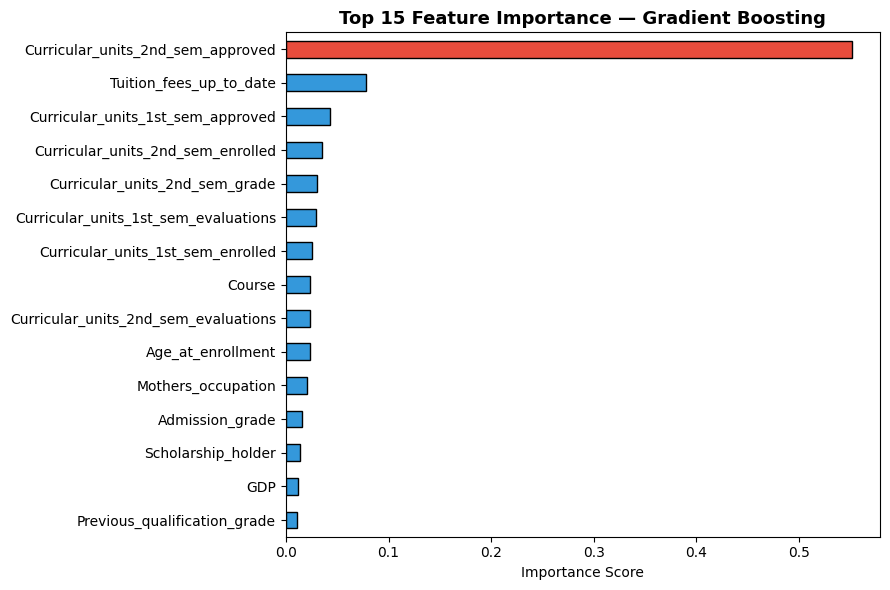


Fitur paling berpengaruh:
Curricular_units_2nd_sem_grade       0.030029
Curricular_units_2nd_sem_enrolled    0.035288
Curricular_units_1st_sem_approved    0.042765
Tuition_fees_up_to_date              0.078157
Curricular_units_2nd_sem_approved    0.551229


In [15]:
# Feature Importance — Top 15
feat_imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if v > 0.1 else '#3498db' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Top 15 Feature Importance — Gradient Boosting', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nFitur paling berpengaruh:')
print(feat_imp.tail(5).to_string())

In [16]:
# Cross-Validation (5-Fold) pada model terbaik
print('Running 5-Fold Cross Validation...')
cv_scores = cross_val_score(gb, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'CV Scores: {cv_scores.round(4)}')
print(f'Mean CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Running 5-Fold Cross Validation...
CV Scores: [0.7655 0.7811 0.7726 0.7853 0.7694]
Mean CV Accuracy: 0.7748 ± 0.0073


## Kesimpulan

### Business Understanding
Jaya Jaya Institut menghadapi masalah tingginya angka dropout mahasiswa (~32% dari total 4.424 mahasiswa). Deteksi dini diperlukan agar institusi dapat memberikan intervensi tepat waktu.

### Temuan Utama
1. **Fitur paling berpengaruh** terhadap dropout adalah jumlah mata kuliah yang disetujui/lulus di semester 1 dan 2 (`Curricular_units_approved`), status pembayaran biaya kuliah (`Tuition_fees_up_to_date`), dan usia saat mendaftar.
2. **Mahasiswa yang tidak membayar biaya kuliah** dan gagal lulus mata kuliah di semester pertama memiliki risiko dropout jauh lebih tinggi.
3. **Model Gradient Boosting** dipilih sebagai model terbaik dengan akurasi **75.93%** dan F1-score weighted **0.75**.

### Rekomendasi Action Items
1. **Early Warning System**: Gunakan model ML yang telah dibuat untuk memonitor mahasiswa secara otomatis setiap akhir semester.
2. **Intervensi Finansial**: Prioritaskan bantuan beasiswa atau keringanan biaya untuk mahasiswa yang menunggak (`Tuition_fees_up_to_date = 0`).
3. **Bimbingan Akademik**: Mahasiswa yang lulus < 3 mata kuliah di semester 1 harus segera mendapat pendampingan akademik.
4. **Program Orientasi**: Mahasiswa lebih tua (>25 tahun) dan mahasiswa internasional perlu dukungan adaptasi khusus.
5. **Dashboard Monitoring**: Gunakan dashboard Metabase untuk memantau tren dropout per kursus dan periode secara real-time.
